Organizing and streamlining code to identify snow-atmosphere interface from SIMBA temperature data to share.

Steps to identify the surface are:

1. calculate the vertical temperature gradient (dTdz)
2. mask known probelm levels, likely not as big an issue or even necessary for summit data
3. vertically scale masked dTdz
4. calculate varaince in time of dTdz
5. identify surface as the maximum variance in each profile

In [185]:
import numpy as np
import matplotlib.pyplot as plt
from netCDF4 import Dataset
import datetime as dt
from sklearn import preprocessing
import csv
from ICECAPS_support_functions import load_raven_sleigh_data, load_netcdf, datetimes_to_seconds, interpolate_and_mask, get_simba_time_of_day
import glob
from cmcrameri import cm as cmr

import matplotlib.dates as mdates
myFmt = mdates.DateFormatter('%m-%d')

#### Functions for sfc id

In [3]:
def load_netcdf(filepath, in_vars):
    """ open netcdf file, load variables (in_vars should be a list) and
        output dictionary of variables"""

    out_vars = {}

    with Dataset(filepath, mode = 'r') as open_netcdf:
        if len(in_vars)>0:
            for var in in_vars:
                out_vars[var] = open_netcdf.variables[var][:]
        else:
            for var in open_netcdf.variables.keys():
                out_vars[var] = open_netcdf.variables[var][:]
    
        try:
            out_vars['time_unit'] = open_netcdf.variables['time'].units
        except:
            None

    return out_vars

In [4]:
def calc_moving_variance(var_in, window):
    for i in range(var_in.shape[0]):
        try:
            time_step_var = np.ma.var(np.ma.masked_invalid(var_in[i-int(window/2):i+int(window/2)+1,:]), axis=0)
        except:
            time_step_var = np.full(var_in.shape[0], -999)

        if i==0:
            rolling_var = time_step_var[np.newaxis,:]
        else:
            rolling_var = np.ma.concatenate((rolling_var, time_step_var[np.newaxis,:]))
    return rolling_var

In [5]:
def mask_variance(var_in, heights_in, dates_in, mask_dict):
    dates_2d = np.repeat(dates_in.copy()[:,np.newaxis], var_in.shape[1], axis=1)
    heights_2d = np.repeat(heights_in.copy()[np.newaxis,:], var_in.shape[0], axis=0)

    data = np.copy(var_in)

    for (d1, d2) in mask_dict:
        mask_height = mask_dict[(d1, d2)]['mask_height']
        if mask_dict[(d1, d2)]['mask_dir'] == 'lessthan':
            data = np.where((dates_2d>=d1)&(dates_2d<d2)&(heights_2d<mask_height), 0, data)
        else:
            data = np.where((dates_2d>=d1)&(dates_2d<d2)&(heights_2d>mask_height), 0, data)
    return data

In [6]:
def mask_then_scale_variance(var_in, heights_in, dates_in, mask_dict=False):
    data = np.copy(var_in)

    if mask_dict:
        data = mask_variance(data, heights_in, dates_in, mask_dict)

    scaled_data = preprocessing.normalize(data, axis=1)
    return scaled_data

In [7]:
def identify_surface(scaled_var_in, heights_in):
    masked_dTdz_var = np.copy(scaled_var_in)
    win_sfc = []
    
    for i in range(masked_dTdz_var.shape[0]):
        timestep_var = masked_dTdz_var[i,:]
        max_height = heights_in[np.ma.where(timestep_var==np.ma.max(timestep_var))[0]]
    
        if len(max_height)!=1:
            win_sfc.append(np.nan)
        else:
            win_sfc.append(max_height[0])
            
    return np.array(win_sfc)

#### Start loading data and making calculations

In [70]:
# simba_filepath = '/psd3data/arctic/sledd/Raven_simba/'
h = 28
simba_fname = f'firnprofile-combined-corrected-at{h}.sled.level2.beta.15min.20240517-20240821_created_September_11_2025.nc'
simba_filepath = '/psd3data/arctic/sledd/Raven_simba/corrections_by_height/'


# simba_data = {}
varnames = ['temperature','initial_height','time']
simba_data = load_netcdf(simba_filepath+simba_fname, varnames)

fstart_time = dt.datetime.strptime(simba_data['time_unit'], 'minutes since %Y-%m-%d')
simba_data['dates'] = np.asarray([fstart_time+dt.timedelta(minutes=int(m)) for m in simba_data['time']])

In [71]:
simba_temps = simba_data['temperature']
simba_heights = simba_data['initial_height']
simba_dates = simba_data['dates']

dTdz = np.gradient(simba_temps, simba_heights,  axis=1)


The SIMBA at Raven had some nuances/issues. The 2x4 used as support for the string introduces noise unrelated to the surface. Melt water below the surface also increases the dT/dz variance. I also did some manual tweaking of surface to make the surface and temperature look more realistic.

They key for each entry is a tuple with the start and end times for when the mask is applied. The values are a dictionary that identify the direction of masking ('mask_dir') as either grater than or less than the 'mask_height'.

In [72]:
obs_in_hr = 4 # SIMBA has resolution of 15 minutes, so 4 observations per hour
win_length = 24 # number of hours to calculate variance over

dTdz_variance = calc_moving_variance(dTdz, obs_in_hr*win_length)

In [73]:
simba_dates_2d = np.repeat(simba_dates.copy()[:,np.newaxis], simba_temps.shape[1], axis=1)
simba_heights_2d = np.repeat(simba_heights.copy()[np.newaxis,:], simba_temps.shape[0], axis=0)

In [74]:
pre_scale_masking = {
           #  (dt.datetime(2024,6,10),dt.datetime(2024,6,10)):{'mask_dir':'lessthan','mask_height':10},
           # (dt.datetime(2024,7,19), dt.datetime(2024,7,21)):{'mask_dir':'greaterthan', 'mask_height':45},
           (dt.datetime(2024,6,10), dt.datetime(2024,6,13)):{'mask_dir':'lessthan','mask_height':10},
           (dt.datetime(2024,5,10), dt.datetime(2024,8,13)):{'mask_dir':'greaterthan','mask_height':60},
           (dt.datetime(2024,5,10), dt.datetime(2024,8,20)):{'mask_dir':'lessthan','mask_height':-5},
           # (dt.datetime(2024,7,1), dt.datetime(2024,8,20)):{'mask_dir':'lessthan','mask_height':25},
           # (dt.datetime(2024,7,27), dt.datetime(2024,8,20)):{'mask_dir':'lessthan','mask_height':40},
           (dt.datetime(2024,5,10), dt.datetime(2024,6,27)):{'mask_dir':'greaterthan','mask_height':45},
           (dt.datetime(2024,5,10), dt.datetime(2024,6,15)):{'mask_dir':'greaterthan','mask_height':35},

           # (dt.datetime(2024,6,19,), dt.datetime(2024,6,21)):{'mask_dir':'greaterthan', 'mask_height':20},
           # (dt.datetime(2024,6,9), dt.datetime(2024,6,13,12)):{'mask_dir':'greaterthan','mask_height':25},
           # (dt.datetime(2024,6,5), dt.datetime(2024,6,12)):{'mask_dir':'greaterthan','mask_height':20},

           (dt.datetime(2024,6,15), dt.datetime(2024,7,1)):{'mask_dir':'lessthan','mask_height':20},
           # (dt.datetime(2024,5,28), dt.datetime(2024,5,31)):{'mask_dir':'greaterthan','mask_height':8},

           # (dt.datetime(2024,6,13), dt.datetime(2024,6,14,12)):{'mask_dir':'greaterthan','mask_height':20},
           # (dt.datetime(2024,6,17,12), dt.datetime(2024,6,18,12)):{'mask_dir':'greaterthan','mask_height':20},
           # (dt.datetime(2024,6,14), dt.datetime(2024,6,18)):{'mask_dir':'greaterthan','mask_height':25},
           # (dt.datetime(2024,7,16), dt.datetime(2024,7,19)):{'mask_dir':'greaterthan','mask_height':48},
           # (dt.datetime(2024,6,8), dt.datetime(2024,6,10)):{'mask_dir':'greaterthan','mask_height':18},
           # (dt.datetime(2024,6,3), dt.datetime(2024,6,5)):{'mask_dir':'greaterthan','mask_height':12},

           (simba_dates[0], simba_dates[-1]):{'mask_dir':'greaterthan','mask_height':100},
           (simba_dates[0], simba_dates[-1]):{'mask_dir':'lessthan','mask_height':-50},
}

In [75]:
dTdz_variance_scaled = mask_then_scale_variance(dTdz_variance, simba_heights, simba_dates, mask_dict=pre_scale_masking)

In [76]:
simba_sfc = identify_surface(dTdz_variance_scaled, simba_heights)

In [77]:
## deal with window artifact in beginning - 
## I didn't do the same for the end because the SIMBA data extends beyond the SLEIGH data I'm using
mean_early_sfc_idx = np.where((simba_dates>dt.datetime(2024,5,17))&(simba_dates<dt.datetime(2024,5,18)))[0]
simba_sfc[np.where(simba_dates<dt.datetime(2024,5,18))] = np.nanmean( simba_sfc[mean_early_sfc_idx])

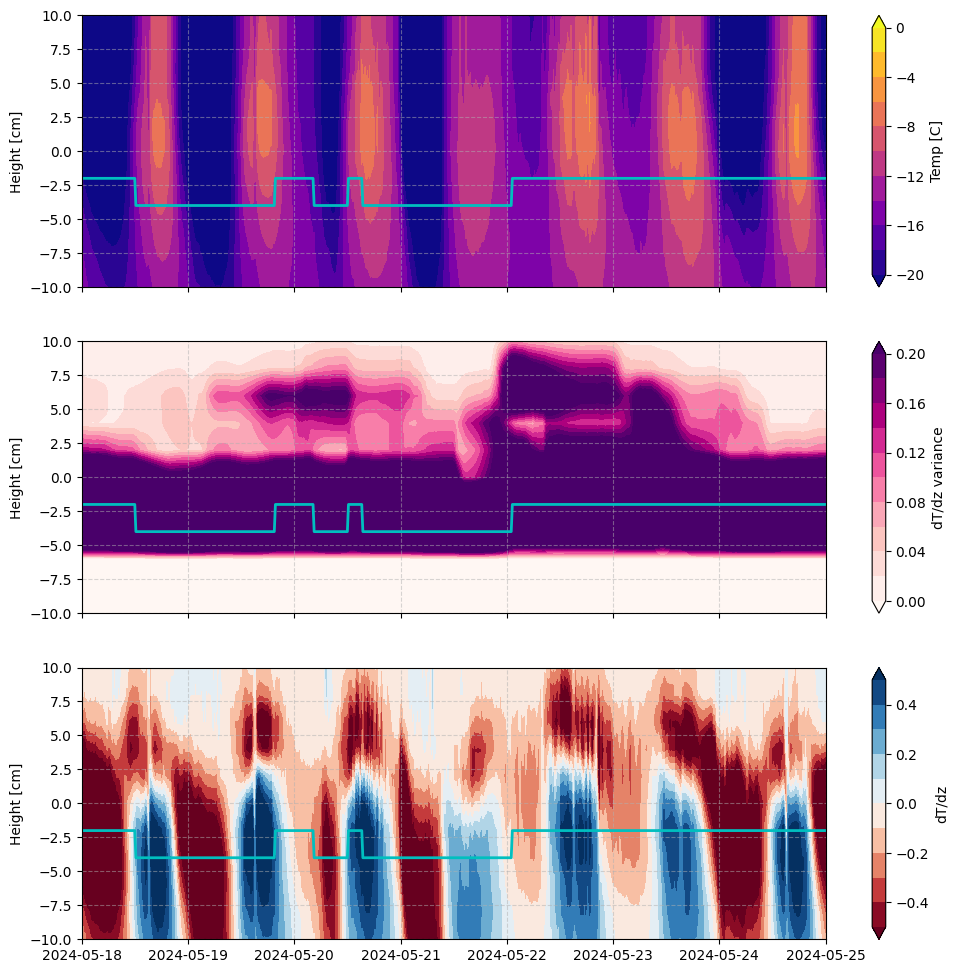

In [104]:
fig, axs = plt.subplots(3, figsize=(12,12), sharex=True, sharey=True)

labels = ['Temp [C]', 'dT/dz variance', 'dT/dz']
cmaps = [plt.cm.plasma, plt.cm.RdPu, plt.cm.RdBu]
levels = [np.arange(-20,1,2), np.arange(0,.21,.02), np.arange(-.5,.51,.1)]

for i, (ax, var) in enumerate(zip(axs.ravel(),[simba_temps, dTdz_variance_scaled, dTdz])):
    cb = ax.contourf(simba_dates, simba_heights, np.swapaxes(var,0,1),
                    cmap=cmaps[i], levels=levels[i], extend='both')
    ax.plot(simba_dates, simba_sfc, c='c', lw=2)
    ax.set_ylabel('Height [cm]')
    plt.colorbar(cb, label=labels[i], ax=ax)
    ax.grid(alpha=.5, ls='--')
# axs[1].set_ylim(-10,60)
# axs[1].set_xlim(dt.datetime(2024,5,18), dt.datetime(2024,7,25))
axs[1].set_ylim(-10,10)
axs[1].set_xlim(dt.datetime(2024,5,18), dt.datetime(2024,5,25))

plt.show()

#### Backup: compare dT/dz for different splices

In [86]:
sleigh_vars = ['up_short_hemisp_qc','up_long_hemisp_qc','down_short_hemisp_qc','down_long_hemisp_qc','subsurface_heat_flux_A_qc',
                  'subsurface_heat_flux_B_qc','skin_temp_surface_qc','temp_qc','snow_depth_qc','zenith_true_qc',
                  'down_short_diffuse','down_short_direct','up_short_hemisp','up_long_hemisp','down_short_hemisp','down_long_hemisp',
                  'snow_depth','temp','brightness_temp_surface','skin_temp_surface','subsurface_heat_flux_A','subsurface_heat_flux_B',
                  'subsurface_heat_flux_C','zenith_true','snow_gpr_dist','base_time','time']

asfs_data_lev2 = load_raven_sleigh_data(sleigh_vars)

In [128]:
print(asfs_data_lev2.keys())

dict_keys(['up_short_hemisp_qc', 'up_long_hemisp_qc', 'down_short_hemisp_qc', 'down_long_hemisp_qc', 'subsurface_heat_flux_A_qc', 'subsurface_heat_flux_B_qc', 'skin_temp_surface_qc', 'temp_qc', 'snow_depth_qc', 'zenith_true_qc', 'down_short_diffuse', 'down_short_direct', 'up_short_hemisp', 'up_long_hemisp', 'down_short_hemisp', 'down_long_hemisp', 'snow_depth', 'temp', 'brightness_temp_surface', 'skin_temp_surface', 'subsurface_heat_flux_A', 'subsurface_heat_flux_B', 'subsurface_heat_flux_C', 'zenith_true', 'snow_gpr_dist', 'dates', 'net_short_hemisp', 'albedo', 'diffuse_frac', 'skin_temp'])


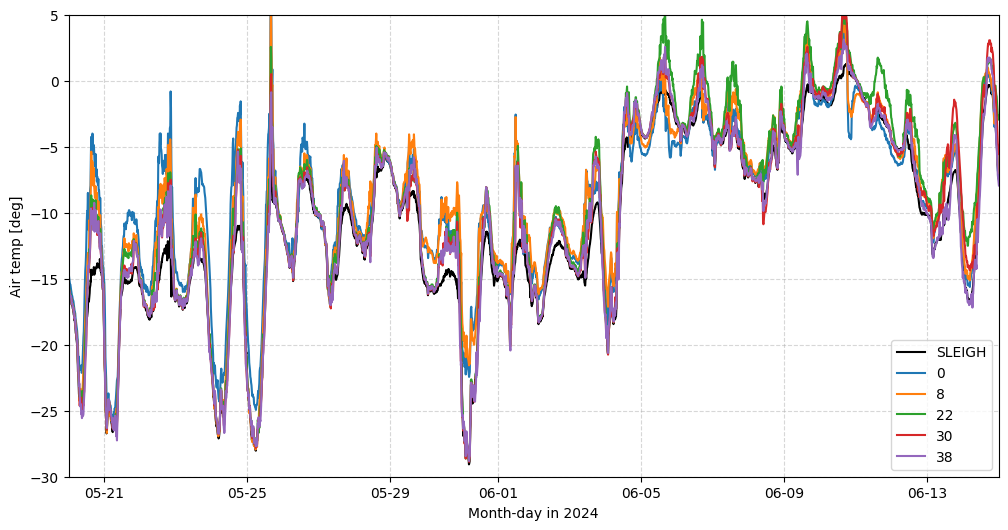

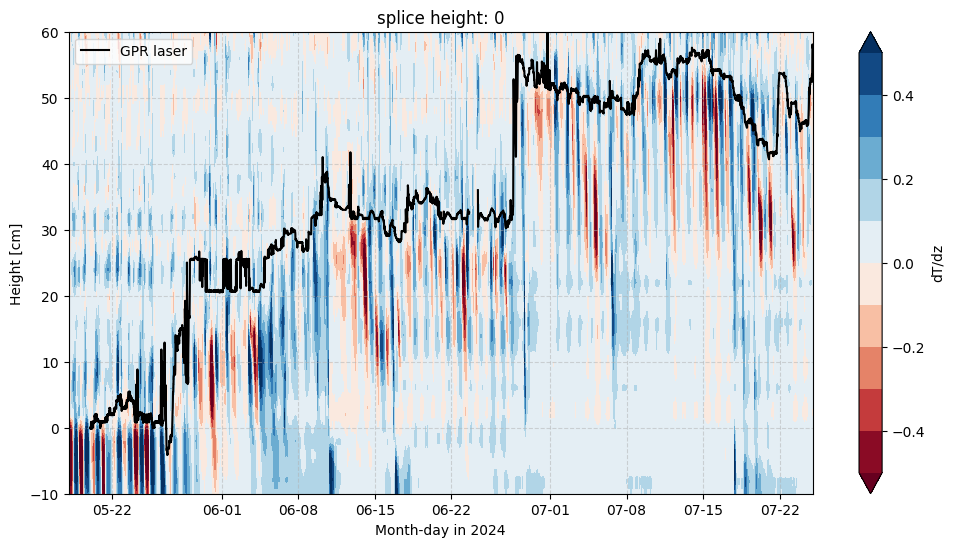

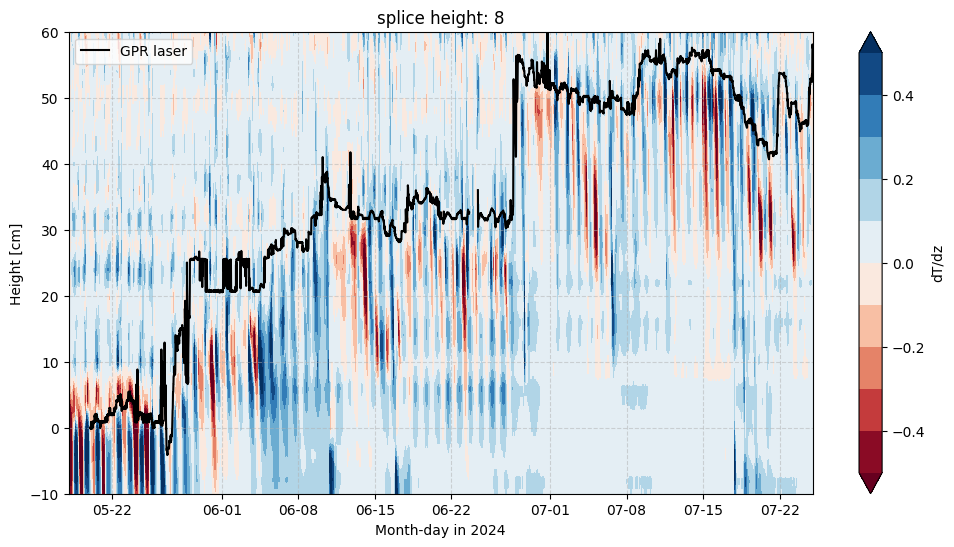

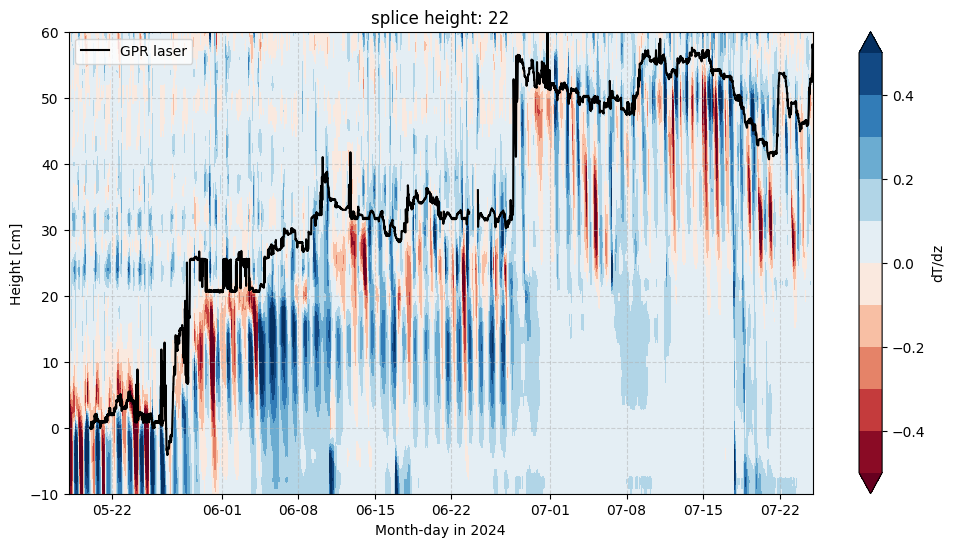

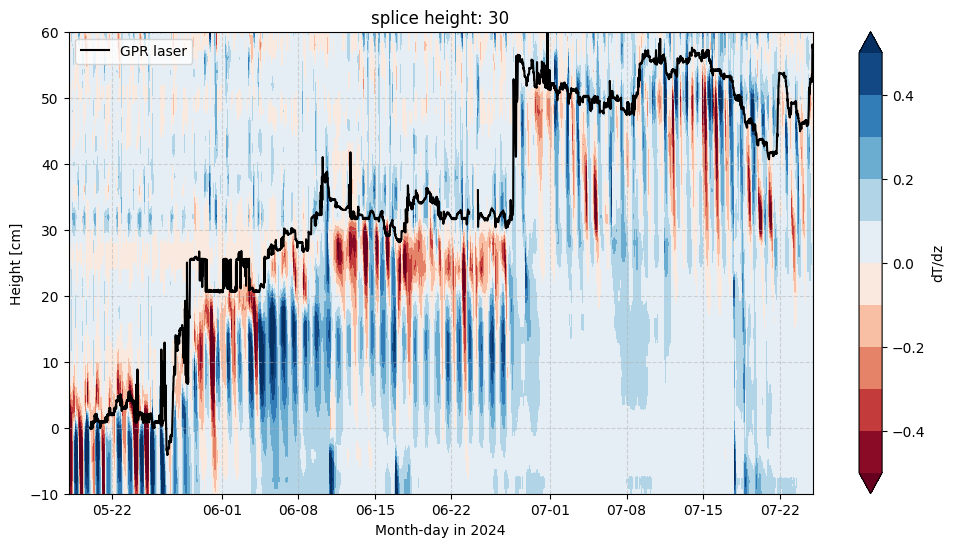

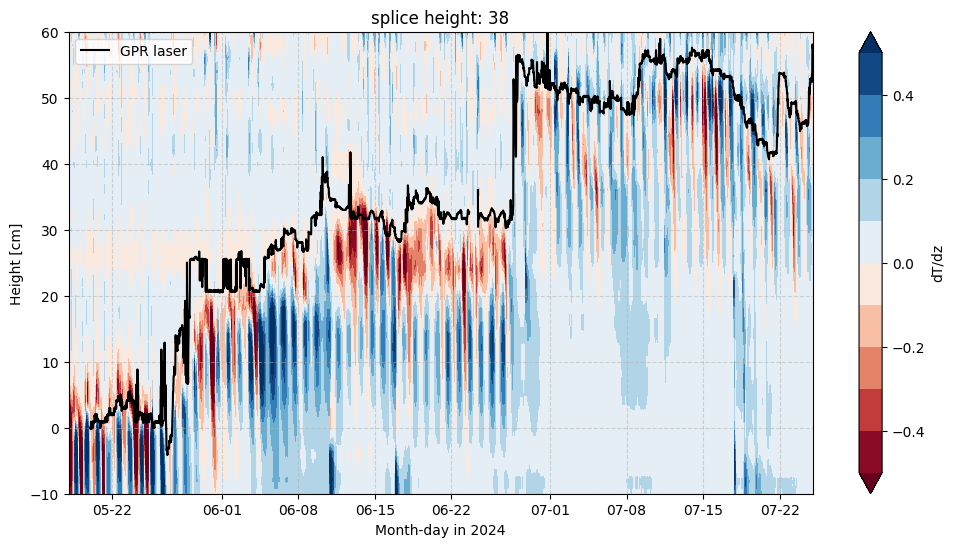

In [103]:
# simba_filepath = '/psd3data/arctic/sledd/Raven_simba/'
h = 28

fig_air, ax_air = plt.subplots(1, figsize=(12,6))

ax_air.plot(asfs_data_lev2['dates'], asfs_data_lev2['temp'], label='SLEIGH', c='k')
ax_air.set_ylabel('Air temp [deg]')
ax_air.set_xlim(dt.datetime(2024,5,18), dt.datetime(2024,7,25))
ax_air.xaxis.set_major_formatter(myFmt)
ax_air.set_xlabel('Month-day in 2024')
ax_air.grid(alpha=.5, ls='--')

for h in [0, 8, 22, 30, 38]:
    simba_fname = f'firnprofile-combined-corrected-at{h}.sled.level2.beta.15min.20240517-20240821_created_September_11_2025.nc'
    simba_filepath = '/psd3data/arctic/sledd/Raven_simba/corrections_by_height/'
    
    
    # simba_data = {}
    varnames = ['temperature','initial_height','time']
    simba_data = load_netcdf(simba_filepath+simba_fname, varnames)
    
    fstart_time = dt.datetime.strptime(simba_data['time_unit'], 'minutes since %Y-%m-%d')
    simba_data['dates'] = np.asarray([fstart_time+dt.timedelta(minutes=int(m)) for m in simba_data['time']])


    simba_temps = simba_data['temperature']
    simba_heights = simba_data['initial_height']
    simba_dates = simba_data['dates']

    ax_air.plot(simba_dates, simba_temps[:,-1], label=h)
    
    dTdz = np.gradient(simba_temps, simba_heights,  axis=1)


    fig, ax = plt.subplots(1, figsize=(12,6), sharex=True, sharey=True)
    cb = ax.contourf(simba_dates, simba_heights, np.swapaxes(dTdz,0,1),
                    cmap=plt.cm.RdBu, levels=np.arange(-.5,.51,.1), extend='both')
    ax.plot(asfs_data_lev2['dates'], (asfs_data_lev2['snow_gpr_dist'][0]-asfs_data_lev2['snow_gpr_dist'])*100., label='GPR laser', c='k')
    ax.set_ylabel('Height [cm]')
    plt.colorbar(cb, label='dT/dz', ax=ax)
    ax.grid(alpha=.5, ls='--')
        
    ax.set_ylim(-10,60)
    ax.set_xlim(dt.datetime(2024,5,18), dt.datetime(2024,7,25))
    ax.xaxis.set_major_formatter(myFmt)
    ax.set_xlabel('Month-day in 2024')
    ax.legend(loc='upper left')
    plt.title(f'splice height: {h}')
    
ax_air.set_ylim(-30,5)
# ax_air.set_xlim(dt.datetime(2024,6,25), dt.datetime(2024,7,25))
ax_air.set_xlim(dt.datetime(2024,5,20), dt.datetime(2024,6,15))

ax_air.legend(loc='best')
plt.show()

negative dT/dz above thermistor is partially a function of splice height??

## checking old sections of SIMBA pre offset correction/splice

In [105]:
simba_filepath = '/psd3data/arctic/sledd/Raven_simba/out_sleigh/'

In [110]:
# simba_filepath = '/psd3data/arctic/raven/simba/level1/'

separate_sections_data = {}
for section in ['bottom', 'top']:
    lev1_files = glob.glob(simba_filepath+f'*{section}.nc')
    
    lev1_files.sort()
    
    ## on our server the simba files include some days from march during testing; this gets rid of those files
    lev1_files = lev1_files[:]

    season_data = {}
    
    for fname in lev1_files[:]:
        fdic = load_netcdf(fname, varnames)
    
        fstart_time = dt.datetime.strptime(fdic['time_unit'][-19:], '%Y-%m-%d %H:%M:%S')
        fdic['dates'] = np.asarray([fstart_time+dt.timedelta(minutes=int(m)) for m in fdic['time']])
    
        for var in ['temperature','dates']:
            if var not in season_data:
                season_data[var] = fdic[var]
            else:
                season_data[var] = np.ma.concatenate( (season_data[var], fdic[var]), axis=0 )
    
        ## only want one height:
        if 'initial_height' not in season_data:
            season_data['initial_height'] = fdic['initial_height']
            
        separate_sections_data[section] = season_data

In [112]:
print(separate_sections_data['top'].keys())

dict_keys(['temperature', 'dates', 'initial_height'])


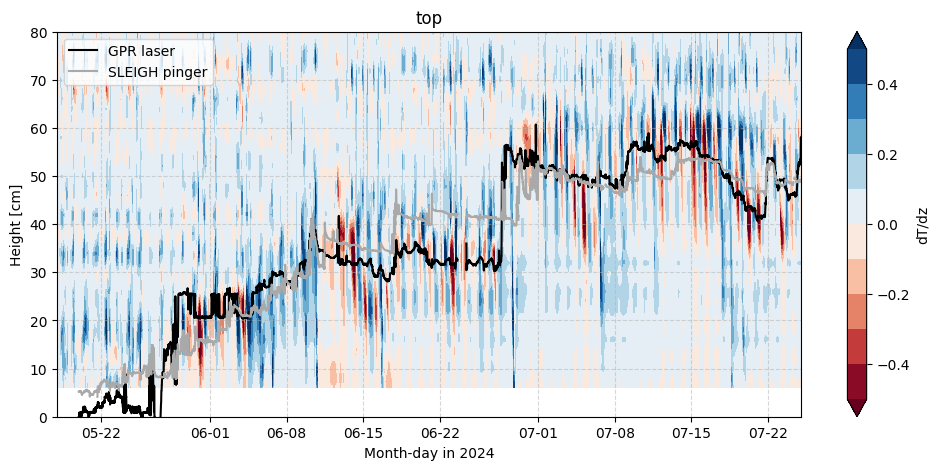

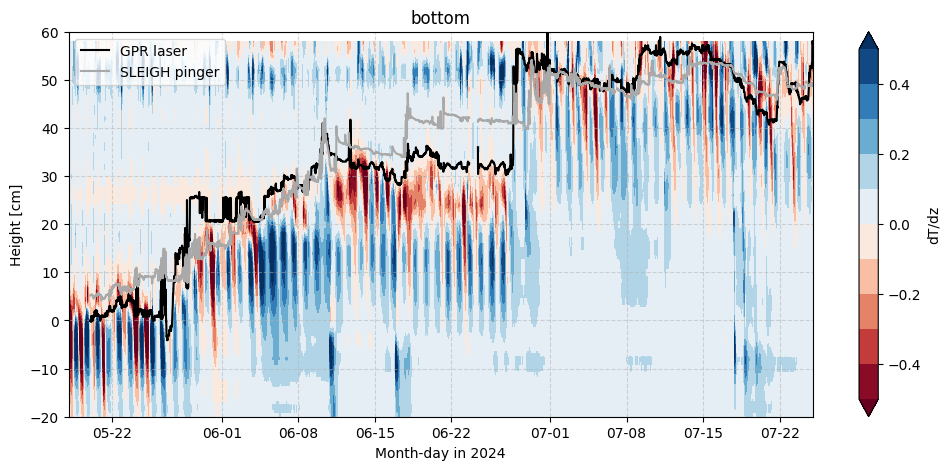

In [122]:
ylims = {'top':(0,80),'bottom':(-20,60)}
for section in ['top','bottom']:
    simba_temps_section = separate_sections_data[section]['temperature']
    simba_heights_section = separate_sections_data[section]['initial_height']
    simba_dates_section = separate_sections_data[section]['dates']
    
    dTdz_section = np.gradient(simba_temps_section, simba_heights_section,  axis=1)

    fig, ax = plt.subplots(1, figsize=(12,5), sharex=True, sharey=True)
    cb = ax.contourf(simba_dates_section, simba_heights_section, np.swapaxes(dTdz_section,0,1),
                    cmap=plt.cm.RdBu, levels=np.arange(-.5,.51,.1), extend='both')
    ax.plot(asfs_data_lev2['dates'], (asfs_data_lev2['snow_gpr_dist'][0]-asfs_data_lev2['snow_gpr_dist'])*100., label='GPR laser', c='k')
    ax.plot( asfs_data_lev2['dates'], asfs_data_lev2['snow_depth'], label='SLEIGH pinger', c='darkgrey')

    ax.set_ylabel('Height [cm]')
    plt.colorbar(cb, label='dT/dz', ax=ax)
    ax.grid(alpha=.5, ls='--')
        
    ax.set_ylim(ylims[section])
    ax.set_xlim(dt.datetime(2024,5,18), dt.datetime(2024,7,25))
    ax.xaxis.set_major_formatter(myFmt)
    ax.set_xlabel('Month-day in 2024')
    ax.legend(loc='upper left')
    plt.title(section)

Top section had melt at surface during "fake" percolation event - could be true for other times as well? how would we explain using the top section with melt that went all the way down but then a gap and then the lower section with melt??



Could it be offsets in individual sensors? 

An unlucky series of offsets, where n+1 is +0.5C and n-1 is -0.5C would lead to a fake gradient of 0.25C/cm, which is maybe the right order of magnitude we're dealing with?

In [ ]:
ylims = {'top':(0,80),'bottom':(-20,60)}
for section in ['top','bottom']:
    simba_temps_section = separate_sections_data[section]['temperature']
    simba_heights_section = separate_sections_data[section]['initial_height']
    simba_dates_section = separate_sections_data[section]['dates']
    
    dTdz_section = np.gradient(simba_temps_section, simba_heights_section,  axis=1)
    dT2dz2_section = np.gradient(dTdz_section, simba_heights_section,  axis=1)

    fig, ax = plt.subplots(1, figsize=(12,5), sharex=True, sharey=True)
    cb = ax.contourf(simba_dates_section, simba_heights_section, np.swapaxes(dT2dz2_section,0,1),
                    cmap=cmr.bam, levels=np.arange(-.1,.11,.01), extend='both')
    ax.plot(asfs_data_lev2['dates'], (asfs_data_lev2['snow_gpr_dist'][0]-asfs_data_lev2['snow_gpr_dist'])*100., label='GPR laser', c='k')
    ax.plot( asfs_data_lev2['dates'], asfs_data_lev2['snow_depth'], label='SLEIGH pinger', c='darkgrey')

    ax.set_ylabel('Height [cm]')
    plt.colorbar(cb, label='d2T/dz2', ax=ax)
    ax.grid(alpha=.5, ls='--')
        
    ax.set_ylim(ylims[section])
    ax.set_xlim(dt.datetime(2024,5,18), dt.datetime(2024,7,25))
    ax.xaxis.set_major_formatter(myFmt)
    ax.set_xlabel('Month-day in 2024')
    ax.legend(loc='upper left')
    plt.title(section)

### comparing time series of temp against SLEIGH observations

In [131]:
sleigh_dates = asfs_data_lev2['dates']
sleigh_air_temp = asfs_data_lev2['temp']
sleigh_skin_temp = asfs_data_lev2['skin_temp'] - 273.15

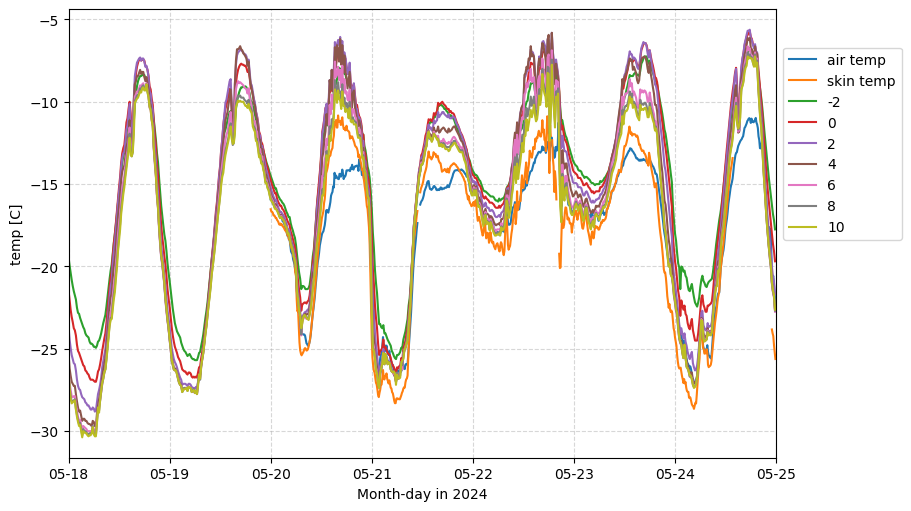

In [143]:
section = 'bottom'
bottom_dates = separate_sections_data[section]['dates']
bottom_temps = separate_sections_data[section]['temperature']
bottom_depths = separate_sections_data[section]['initial_height']


t1, t2 = dt.datetime(2024,5,18), dt.datetime(2024,5,25)
depths = np.arange(-2,11,2)
# depths = np.arange(20,30,2)

simb_time_idx = np.where((bottom_dates>=t1)&(bottom_dates<t2))
sleigh_time_idx = np.where((sleigh_dates>=t1)&(sleigh_dates<t2))

fig, ax = plt.subplots(1, figsize=(9,5), constrained_layout=True)
ax.plot(sleigh_dates[sleigh_time_idx], sleigh_air_temp[sleigh_time_idx], label='air temp')
ax.plot(sleigh_dates[sleigh_time_idx], sleigh_skin_temp[sleigh_time_idx], label='skin temp')

for d in depths:
    depth_idx = np.where(bottom_depths==d)[0]
    ax.plot(bottom_dates[simb_time_idx], np.squeeze(bottom_temps[simb_time_idx[0],:][:,depth_idx]), label=d )

ax.grid(alpha=.5, ls='--')
ax.legend(loc='center left', bbox_to_anchor=(1, .7))
ax.set_ylabel('temp [C]')
ax.xaxis.set_major_formatter(myFmt)
ax.set_xlabel('Month-day in 2024')
ax.set_xlim(t1, t2)
plt.show()

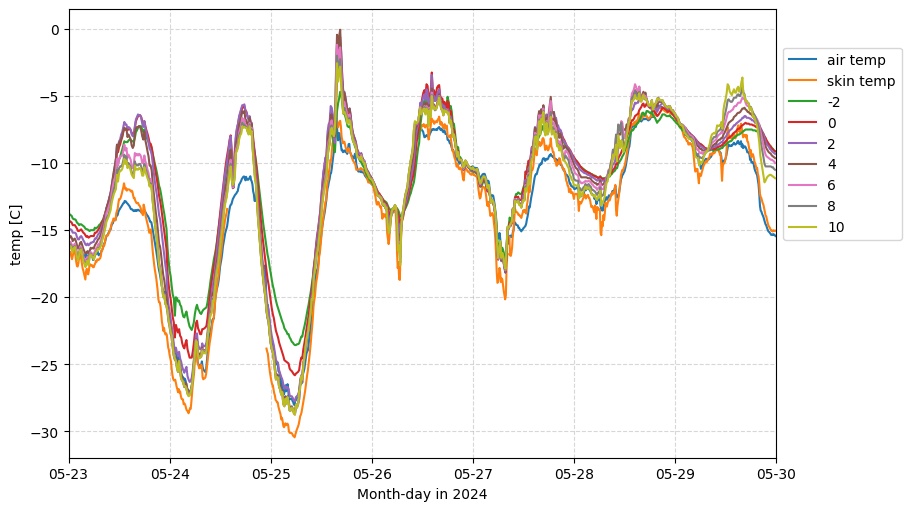

In [221]:
section = 'bottom'
bottom_dates = separate_sections_data[section]['dates']
bottom_temps = separate_sections_data[section]['temperature']
bottom_depths = separate_sections_data[section]['initial_height']


t1, t2 = dt.datetime(2024,5,23), dt.datetime(2024,5,30)
depths = np.arange(-2,11,2)
# depths = np.arange(20,30,2)

simb_time_idx = np.where((bottom_dates>=t1)&(bottom_dates<t2))
sleigh_time_idx = np.where((sleigh_dates>=t1)&(sleigh_dates<t2))

fig, ax = plt.subplots(1, figsize=(9,5), constrained_layout=True)
ax.plot(sleigh_dates[sleigh_time_idx], sleigh_air_temp[sleigh_time_idx], label='air temp')
ax.plot(sleigh_dates[sleigh_time_idx], sleigh_skin_temp[sleigh_time_idx], label='skin temp')

for d in depths:
    depth_idx = np.where(bottom_depths==d)[0]
    ax.plot(bottom_dates[simb_time_idx], np.squeeze(bottom_temps[simb_time_idx[0],:][:,depth_idx]), label=d )

ax.grid(alpha=.5, ls='--')
ax.legend(loc='center left', bbox_to_anchor=(1, .7))
ax.set_ylabel('temp [C]')
ax.xaxis.set_major_formatter(myFmt)
ax.set_xlabel('Month-day in 2024')
ax.set_xlim(t1, t2)
plt.show()

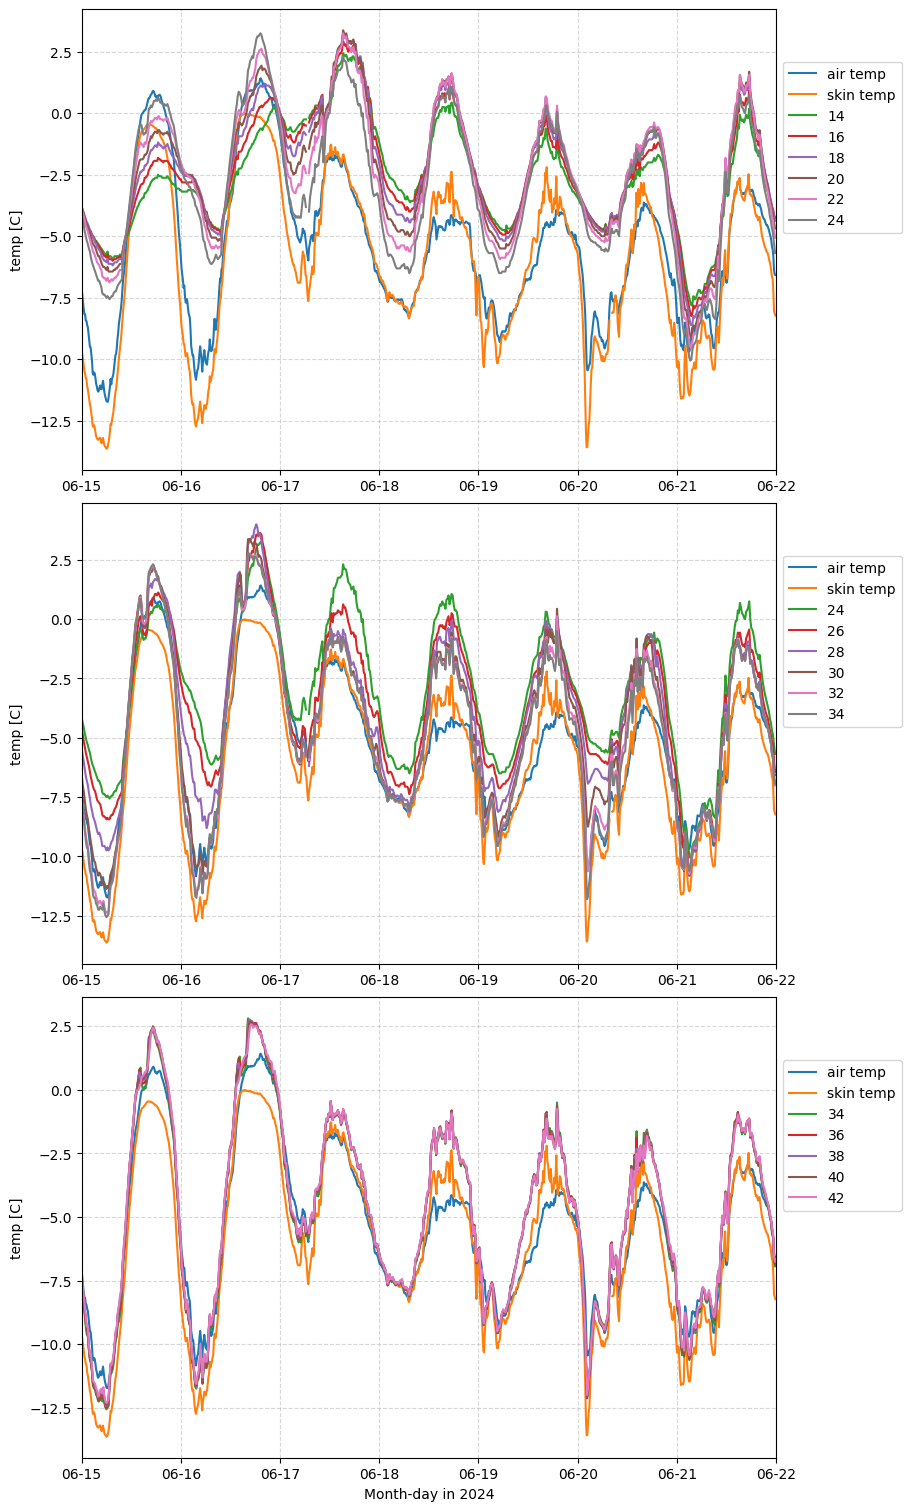

In [148]:
fig, axs = plt.subplots(3, figsize=(9,15), constrained_layout=True)


t1, t2 = dt.datetime(2024,6,15), dt.datetime(2024,6,22)


depth_intervals = [np.arange(14,26,2), np.arange(24,36,2), np.arange(34,44,2)]
# depths = np.arange(20,30,2)

simb_time_idx = np.where((bottom_dates>=t1)&(bottom_dates<t2))
sleigh_time_idx = np.where((sleigh_dates>=t1)&(sleigh_dates<t2))

for ax, depths in zip(axs.ravel(), depth_intervals):

    ax.plot(sleigh_dates[sleigh_time_idx], sleigh_air_temp[sleigh_time_idx], label='air temp')
    ax.plot(sleigh_dates[sleigh_time_idx], sleigh_skin_temp[sleigh_time_idx], label='skin temp')
    
    for d in depths:
        depth_idx = np.where(bottom_depths==d)[0]
        ax.plot(bottom_dates[simb_time_idx], np.squeeze(bottom_temps[simb_time_idx[0],:][:,depth_idx]), label=d )
    
    ax.grid(alpha=.5, ls='--')
    ax.legend(loc='center left', bbox_to_anchor=(1, .7))
    ax.set_ylabel('temp [C]')
    ax.xaxis.set_major_formatter(myFmt)
    
    ax.set_xlim(t1, t2)
    
axs[-1].set_xlabel('Month-day in 2024')
plt.show()

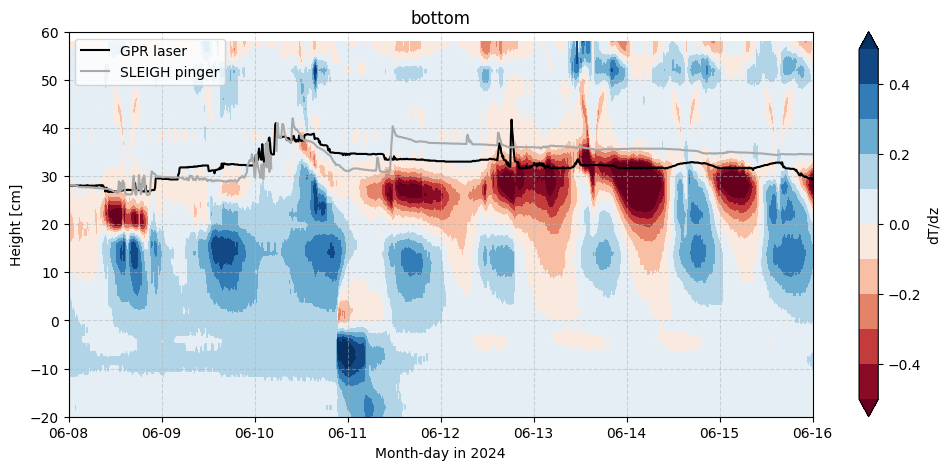

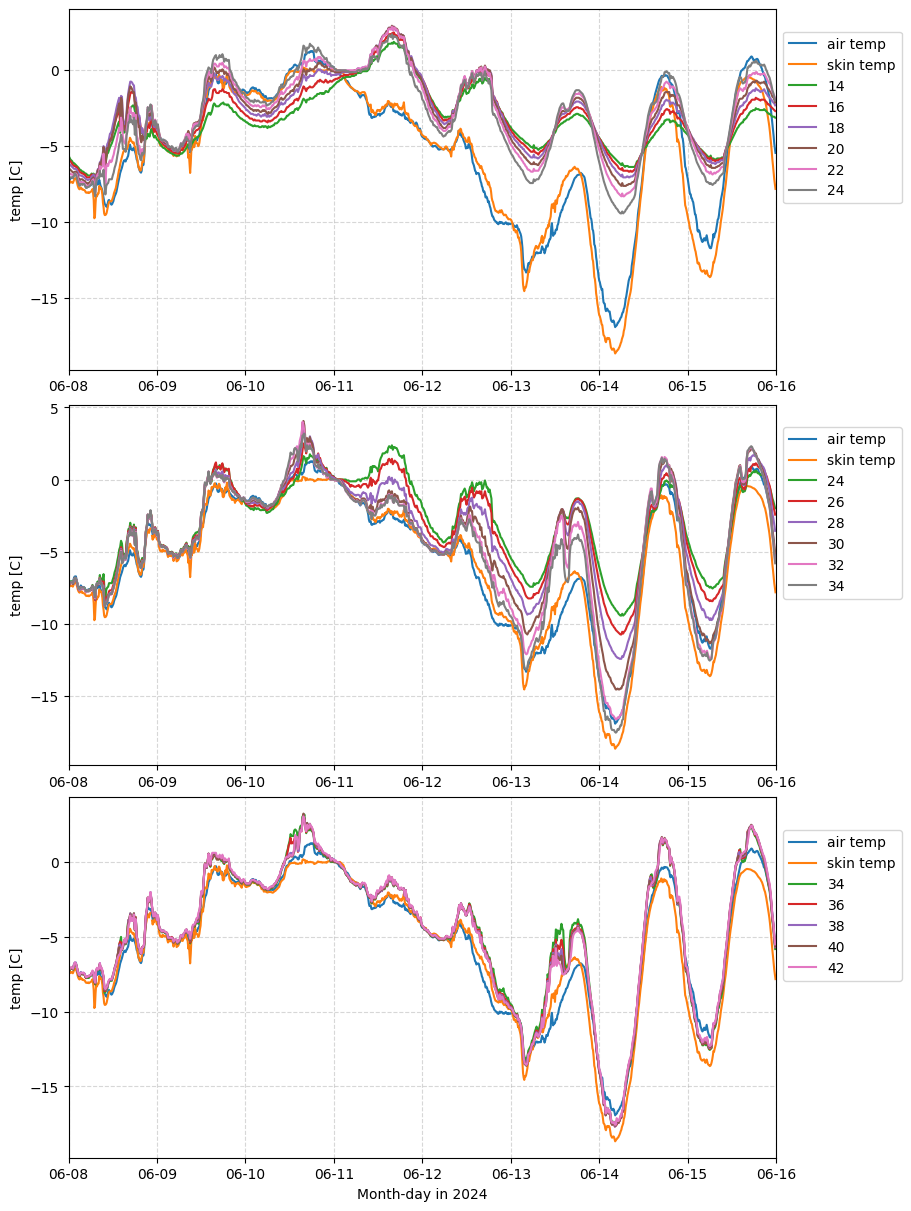

In [156]:

t1, t2 = dt.datetime(2024,6,8), dt.datetime(2024,6,16)

ylims = {'top':(0,80),'bottom':(-20,60)}
for section in ['bottom']:
    simba_temps_section = separate_sections_data[section]['temperature']
    simba_heights_section = separate_sections_data[section]['initial_height']
    simba_dates_section = separate_sections_data[section]['dates']
    
    dTdz_section = np.gradient(simba_temps_section, simba_heights_section,  axis=1)

    fig, ax = plt.subplots(1, figsize=(12,5), sharex=True, sharey=True)
    cb = ax.contourf(simba_dates_section, simba_heights_section, np.swapaxes(dTdz_section,0,1),
                    cmap=plt.cm.RdBu, levels=np.arange(-.5,.51,.1), extend='both')
    ax.plot(asfs_data_lev2['dates'], (asfs_data_lev2['snow_gpr_dist'][0]-asfs_data_lev2['snow_gpr_dist'])*100., label='GPR laser', c='k')
    ax.plot( asfs_data_lev2['dates'], asfs_data_lev2['snow_depth'], label='SLEIGH pinger', c='darkgrey')

    ax.set_ylabel('Height [cm]')
    plt.colorbar(cb, label='dT/dz', ax=ax)
    ax.grid(alpha=.5, ls='--')
        
    ax.set_ylim(ylims[section])
    ax.set_xlim(t1,t2)
    ax.xaxis.set_major_formatter(myFmt)
    ax.set_xlabel('Month-day in 2024')
    ax.legend(loc='upper left')
    plt.title(section)

plt.show()

fig, axs = plt.subplots(3, figsize=(9,12), constrained_layout=True)


depth_intervals = [np.arange(14,26,2), np.arange(24,36,2), np.arange(34,44,2)]
# depths = np.arange(20,30,2)

simb_time_idx = np.where((bottom_dates>=t1)&(bottom_dates<t2))
sleigh_time_idx = np.where((sleigh_dates>=t1)&(sleigh_dates<t2))

for ax, depths in zip(axs.ravel(), depth_intervals):

    ax.plot(sleigh_dates[sleigh_time_idx], sleigh_air_temp[sleigh_time_idx], label='air temp')
    ax.plot(sleigh_dates[sleigh_time_idx], sleigh_skin_temp[sleigh_time_idx], label='skin temp')
    
    for d in depths:
        depth_idx = np.where(bottom_depths==d)[0]
        ax.plot(bottom_dates[simb_time_idx], np.squeeze(bottom_temps[simb_time_idx[0],:][:,depth_idx]), label=d )
    
    ax.grid(alpha=.5, ls='--')
    ax.legend(loc='center left', bbox_to_anchor=(1, .7))
    ax.set_ylabel('temp [C]')
    ax.xaxis.set_major_formatter(myFmt)
    
    ax.set_xlim(t1, t2)
    
axs[-1].set_xlabel('Month-day in 2024')
plt.show()

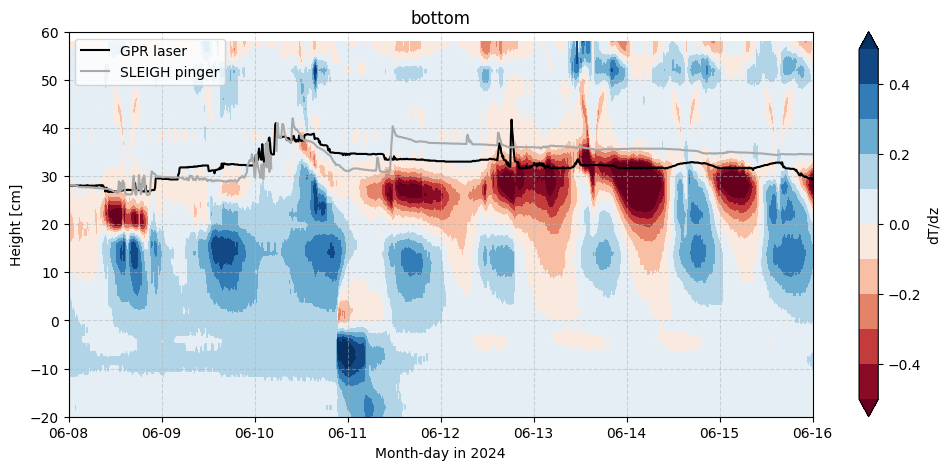

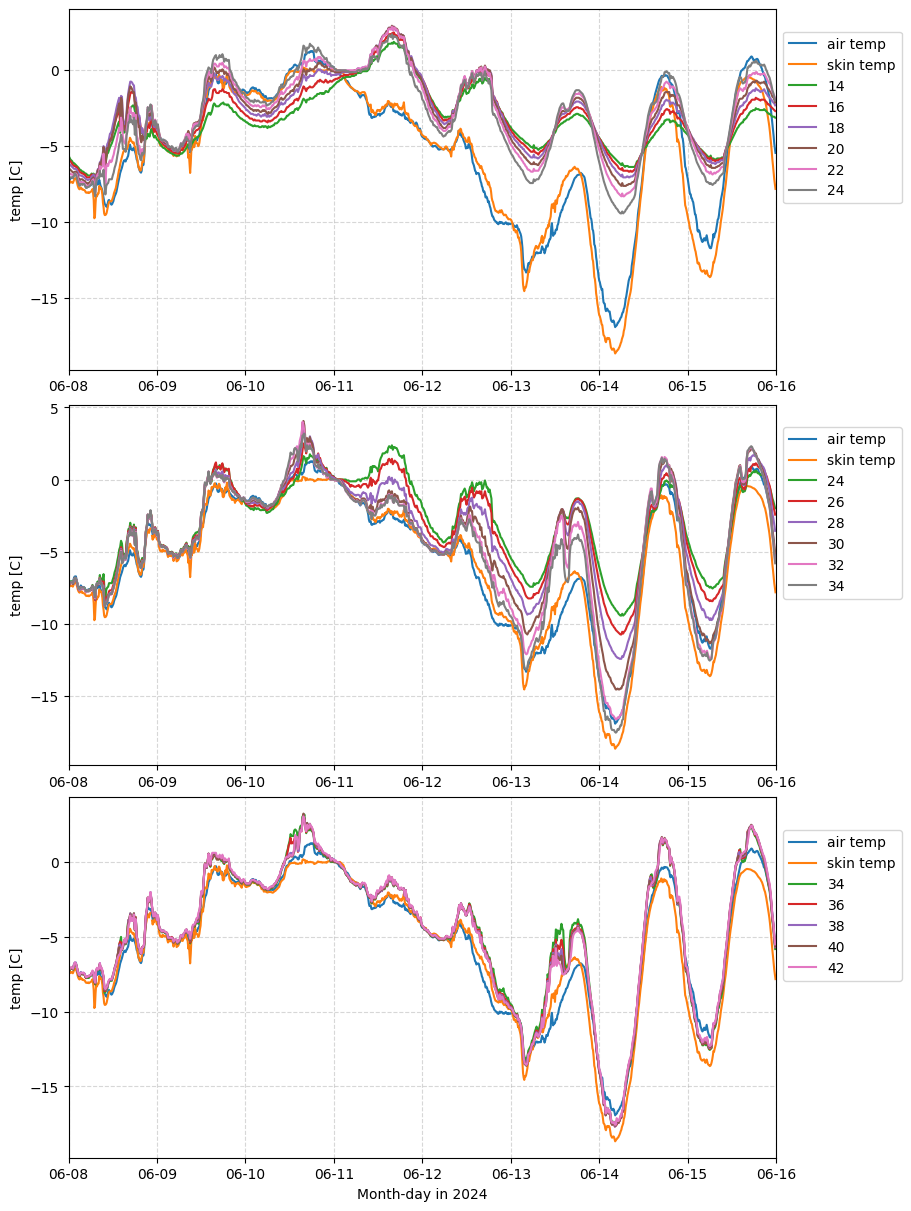

In [157]:
t1, t2 = dt.datetime(2024,6,8), dt.datetime(2024,6,16)
ylims = {'top':(0,80),'bottom':(-20,60)}
for section in ['bottom']:
    simba_temps_section = separate_sections_data[section]['temperature']
    simba_heights_section = separate_sections_data[section]['initial_height']
    simba_dates_section = separate_sections_data[section]['dates']
    
    dTdz_section = np.gradient(simba_temps_section, simba_heights_section,  axis=1)

    fig, ax = plt.subplots(1, figsize=(12,5), sharex=True, sharey=True)
    cb = ax.contourf(simba_dates_section, simba_heights_section, np.swapaxes(dTdz_section,0,1),
                    cmap=plt.cm.RdBu, levels=np.arange(-.5,.51,.1), extend='both')
    ax.plot(asfs_data_lev2['dates'], (asfs_data_lev2['snow_gpr_dist'][0]-asfs_data_lev2['snow_gpr_dist'])*100., label='GPR laser', c='k')
    ax.plot( asfs_data_lev2['dates'], asfs_data_lev2['snow_depth'], label='SLEIGH pinger', c='darkgrey')

    ax.set_ylabel('Height [cm]')
    plt.colorbar(cb, label='dT/dz', ax=ax)
    ax.grid(alpha=.5, ls='--')
        
    ax.set_ylim(ylims[section])
    ax.set_xlim(t1,t2)
    ax.xaxis.set_major_formatter(myFmt)
    ax.set_xlabel('Month-day in 2024')
    ax.legend(loc='upper left')
    plt.title(section)

plt.show()

fig, axs = plt.subplots(3, figsize=(9,12), constrained_layout=True)


depth_intervals = [np.arange(14,26,2), np.arange(24,36,2), np.arange(34,44,2)]
# depths = np.arange(20,30,2)

simb_time_idx = np.where((bottom_dates>=t1)&(bottom_dates<t2))
sleigh_time_idx = np.where((sleigh_dates>=t1)&(sleigh_dates<t2))

for ax, depths in zip(axs.ravel(), depth_intervals):

    ax.plot(sleigh_dates[sleigh_time_idx], sleigh_air_temp[sleigh_time_idx], label='air temp')
    ax.plot(sleigh_dates[sleigh_time_idx], sleigh_skin_temp[sleigh_time_idx], label='skin temp')
    
    for d in depths:
        depth_idx = np.where(bottom_depths==d)[0]
        ax.plot(bottom_dates[simb_time_idx], np.squeeze(bottom_temps[simb_time_idx[0],:][:,depth_idx]), label=d )
    
    ax.grid(alpha=.5, ls='--')
    ax.legend(loc='center left', bbox_to_anchor=(1, .7))
    ax.set_ylabel('temp [C]')
    ax.xaxis.set_major_formatter(myFmt)
    
    ax.set_xlim(t1, t2)
    
axs[-1].set_xlabel('Month-day in 2024')
plt.show()

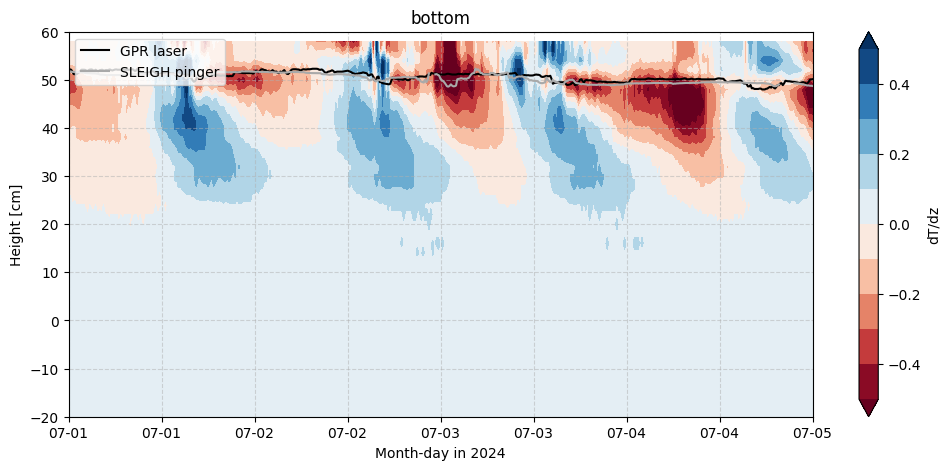

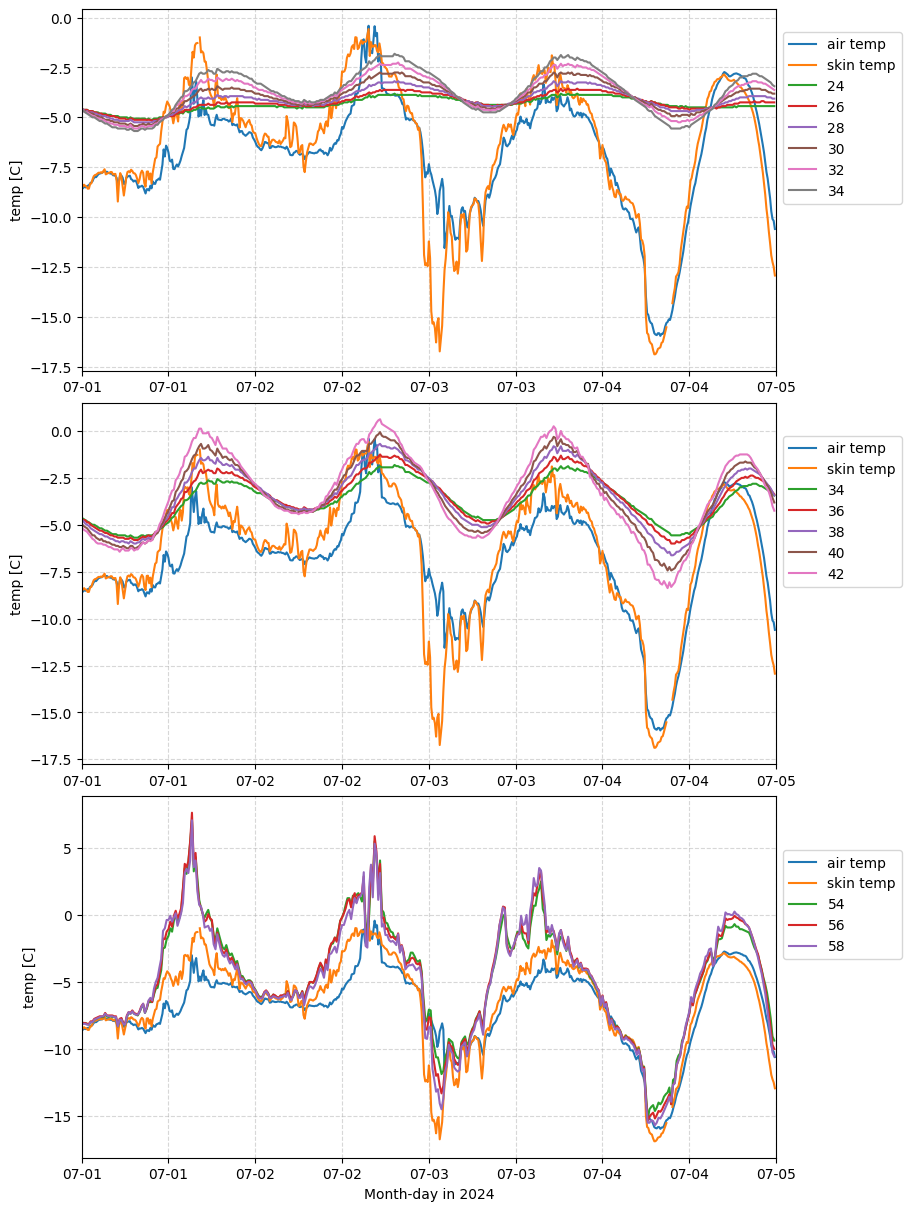

In [286]:

t1, t2 = dt.datetime(2024,7,1), dt.datetime(2024,7,5)
ylims = {'top':(0,80),'bottom':(-20,60)}
for section in ['bottom']:
    simba_temps_section = separate_sections_data[section]['temperature']
    simba_heights_section = separate_sections_data[section]['initial_height']
    simba_dates_section = separate_sections_data[section]['dates']
    
    dTdz_section = np.gradient(simba_temps_section, simba_heights_section,  axis=1)

    fig, ax = plt.subplots(1, figsize=(12,5), sharex=True, sharey=True)
    cb = ax.contourf(simba_dates_section, simba_heights_section, np.swapaxes(dTdz_section,0,1),
                    cmap=plt.cm.RdBu, levels=np.arange(-.5,.51,.1), extend='both')
    ax.plot(asfs_data_lev2['dates'], (asfs_data_lev2['snow_gpr_dist'][0]-asfs_data_lev2['snow_gpr_dist'])*100., label='GPR laser', c='k')
    ax.plot( asfs_data_lev2['dates'], asfs_data_lev2['snow_depth'], label='SLEIGH pinger', c='darkgrey')

    ax.set_ylabel('Height [cm]')
    plt.colorbar(cb, label='dT/dz', ax=ax)
    ax.grid(alpha=.5, ls='--')
        
    ax.set_ylim(ylims[section])
    ax.set_xlim(t1,t2)
    ax.xaxis.set_major_formatter(myFmt)
    ax.set_xlabel('Month-day in 2024')
    ax.legend(loc='upper left')
    plt.title(section)

plt.show()

fig, axs = plt.subplots(3, figsize=(9,12), constrained_layout=True)




depth_intervals = [np.arange(24,36,2), np.arange(34,44,2), np.arange(54,64,2)]
# depths = np.arange(20,30,2)

simb_time_idx = np.where((bottom_dates>=t1)&(bottom_dates<t2))
sleigh_time_idx = np.where((sleigh_dates>=t1)&(sleigh_dates<t2))

for ax, depths in zip(axs.ravel(), depth_intervals):

    ax.plot(sleigh_dates[sleigh_time_idx], sleigh_air_temp[sleigh_time_idx], label='air temp')
    ax.plot(sleigh_dates[sleigh_time_idx], sleigh_skin_temp[sleigh_time_idx], label='skin temp')
    
    for d in depths:
        depth_idx = np.where(bottom_depths==d)[0]
        ax.plot(bottom_dates[simb_time_idx], np.squeeze(bottom_temps[simb_time_idx[0],:][:,depth_idx]), label=d )
    
    ax.grid(alpha=.5, ls='--')
    ax.legend(loc='center left', bbox_to_anchor=(1, .7))
    ax.set_ylabel('temp [C]')
    ax.xaxis.set_major_formatter(myFmt)
    
    ax.set_xlim(t1, t2)
    
axs[-1].set_xlabel('Month-day in 2024')
plt.show()

In [166]:
simba_secs = datetimes_to_seconds(bottom_dates)
sleigh_secs = datetimes_to_seconds(sleigh_dates)

skin_temp_simba_steps = interpolate_and_mask(sleigh_skin_temp, sleigh_secs, simba_secs)

In [167]:
## mask same steps again
mask_sleigh = np.zeros(sleigh_skin_temp.shape)
mask_sleigh[sleigh_skin_temp.mask] = 1
interp_mask_sleigh = interpolate_and_mask(mask_sleigh, sleigh_secs, simba_secs)

skin_temp_simba_steps = np.ma.masked_where(interp_mask_sleigh!=0, skin_temp_simba_steps)

In [168]:
skin_temp_simba_steps_2d = np.repeat(skin_temp_simba_steps[:,np.newaxis], bottom_temps.shape[1], axis=1)

In [171]:
simba_skin_diff = bottom_temps-skin_temp_simba_steps_2d

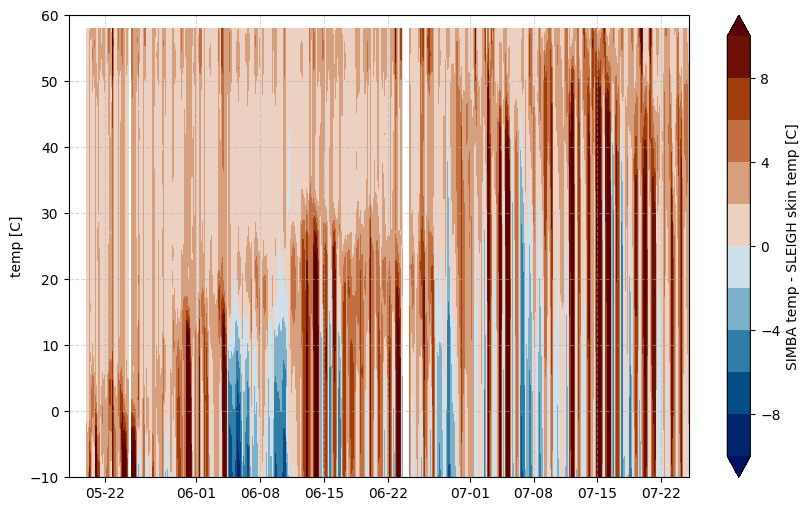

In [176]:
fig, ax = plt.subplots(1, figsize=(10,6))
cb = ax.contourf(bottom_dates, bottom_depths, np.swapaxes(simba_skin_diff,0,1), levels=np.arange(-10,11,2), extend='both', cmap=cmr.vik )
ax.grid(alpha=.5, ls='--')
ax.set_ylabel('temp [C]')
ax.xaxis.set_major_formatter(myFmt)
plt.colorbar(cb, label='SIMBA temp - SLEIGH skin temp [C]')
ax.set_xlim(dt.datetime(2024,5,18), dt.datetime(2024,7,25))
axs[-1].set_xlabel('Month-day in 2024')

ax.set_ylim(-10,60)
plt.show()

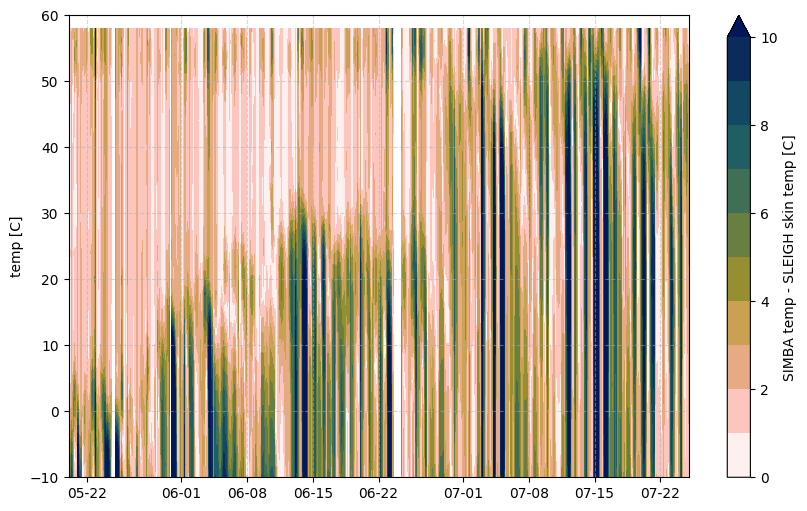

In [181]:
fig, ax = plt.subplots(1, figsize=(10,6))
cb = ax.contourf(bottom_dates, bottom_depths, np.swapaxes(np.abs(simba_skin_diff),0,1), levels=np.arange(0,11,1), 
                 extend='max', cmap=cmr.batlowW_r )
ax.grid(alpha=.5, ls='--')
ax.set_ylabel('temp [C]')
ax.xaxis.set_major_formatter(myFmt)
plt.colorbar(cb, label='SIMBA temp - SLEIGH skin temp [C]')
ax.set_xlim(dt.datetime(2024,5,20), dt.datetime(2024,7,25))
axs[-1].set_xlabel('Month-day in 2024')

ax.set_ylim(-10,60)
plt.show()

In [188]:
simba_tod = get_simba_time_of_day(bottom_dates)
simba_tod_2d = np.repeat(simba_tod[:,np.newaxis], bottom_temps.shape[1], axis=1)

In [196]:
simba_height_2d = np.repeat(bottom_depths[np.newaxis,:], bottom_temps.shape[0], axis=0)

In [203]:
bottom_dates_2d = np.repeat(bottom_dates[:,np.newaxis], bottom_temps.shape[1], axis=1)

In [205]:
print(simba_height_2d.shape, bottom_dates_2d.shape)

(8640, 89) (8640, 89)


In [222]:
abs_temp_diff_night = np.ma.masked_where(simba_tod_2d>6, np.ma.abs(simba_skin_diff))
abs_temp_diff_night = np.ma.masked_where(simba_height_2d<0, abs_temp_diff_night)

min_diff_vals = np.ma.min(abs_temp_diff_night, axis=1)
print(min_diff_vals.shape)
min_diff_vals_2d = np.repeat(min_diff_vals[:,np.newaxis], bottom_temps.shape[1], axis=1)

print(min_diff_vals.shape, min_diff_vals_2d.shape, abs_temp_diff_night.shape)

min_height_idx = np.ma.where(min_diff_vals_2d==abs_temp_diff_night)

min_height_vals = simba_height_2d[min_height_idx]
min_height_dates = bottom_dates_2d[min_height_idx]

(8640,)
(8640,) (8640, 89) (8640, 89)


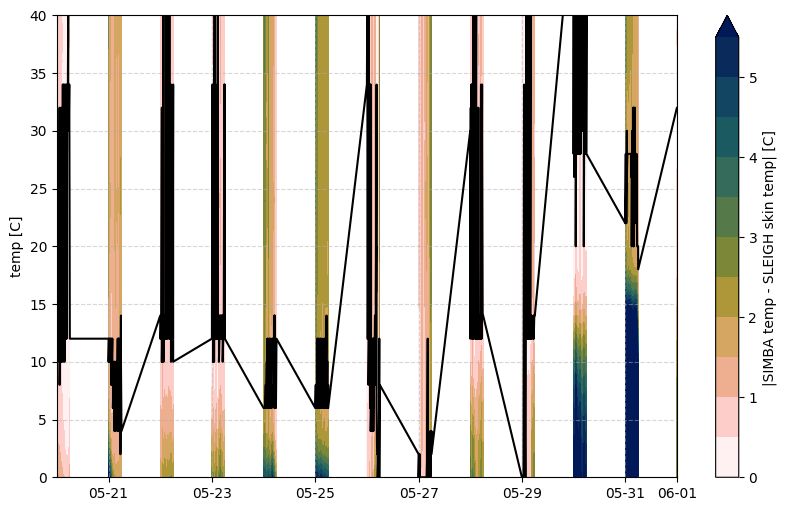

In [225]:
fig, ax = plt.subplots(1, figsize=(10,6))
cb = ax.contourf(bottom_dates, bottom_depths, np.swapaxes(abs_temp_diff_night,0,1), levels=np.arange(0,6,.5), 
                cmap=cmr.batlowW_r, extend='max')

ax.plot(min_height_dates, min_height_vals, c='k')
ax.grid(alpha=.5, ls='--')
ax.set_ylabel('temp [C]')
ax.xaxis.set_major_formatter(myFmt)
plt.colorbar(cb, label='|SIMBA temp - SLEIGH skin temp| [C]')
ax.set_xlim(dt.datetime(2024,5,20), dt.datetime(2024,6,1))
axs[-1].set_xlabel('Month-day in 2024')

ax.set_ylim(0,40)
plt.show()

Not feeling up to operationalizing this, just brute force for now...

In [231]:
myFmt_hr = mdates.DateFormatter('%m-%d %H')

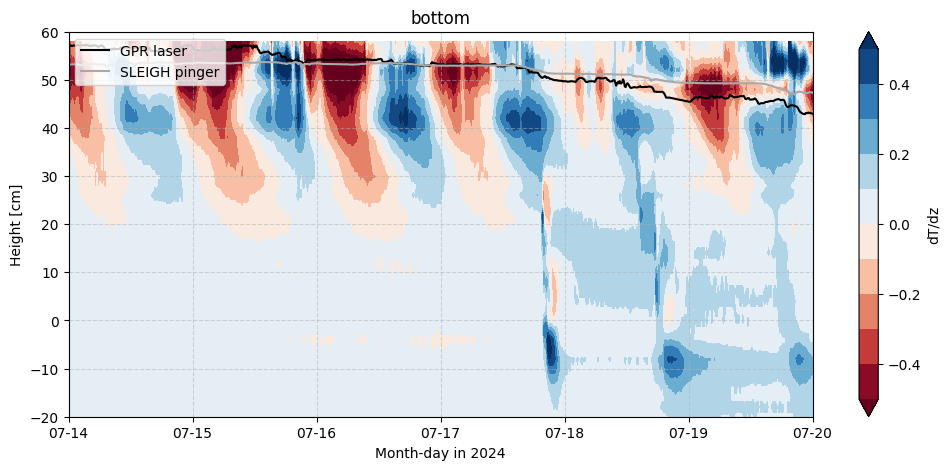

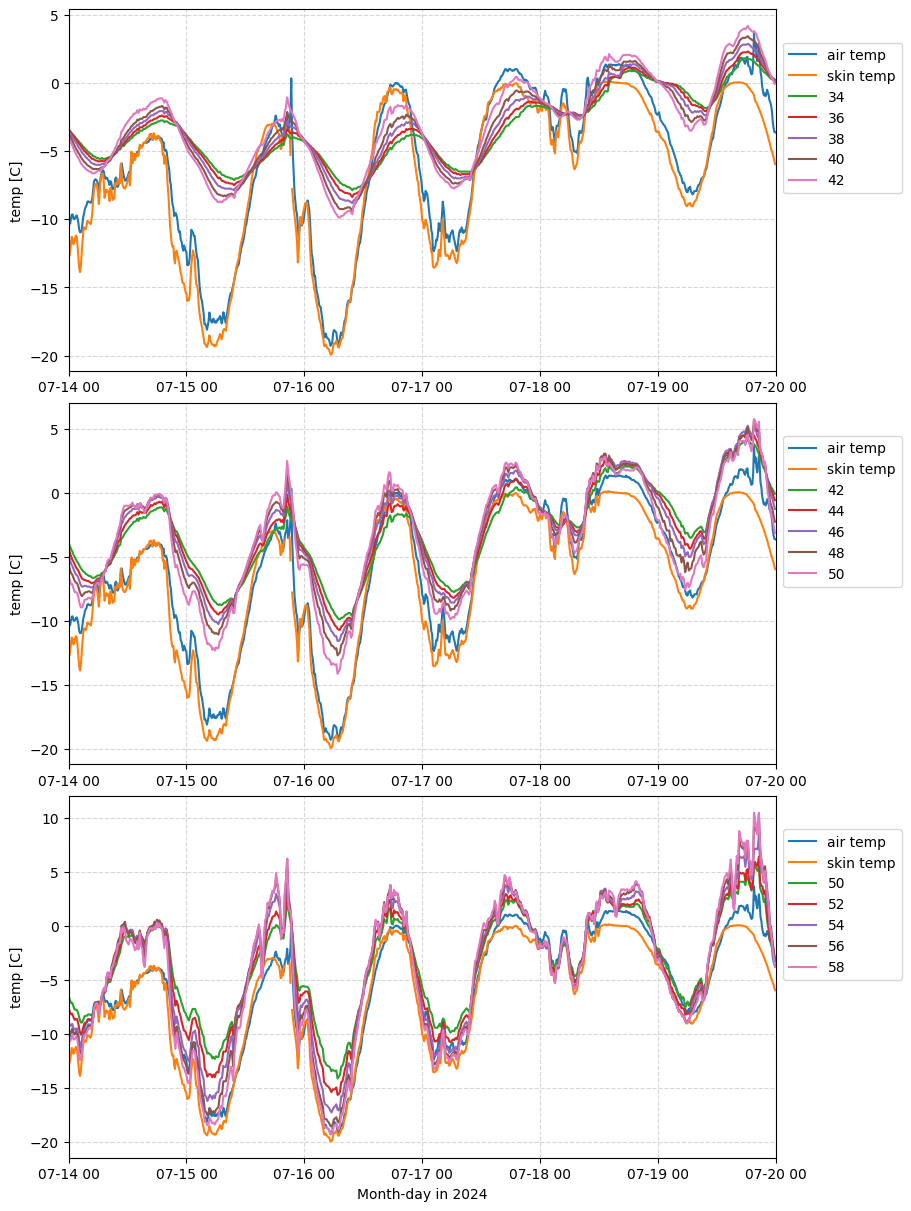

In [291]:

t1, t2 = dt.datetime(2024,7,14), dt.datetime(2024,7,20)

ylims = {'top':(0,80),'bottom':(-20,60)}
for section in ['bottom']:
    simba_temps_section = separate_sections_data[section]['temperature']
    simba_heights_section = separate_sections_data[section]['initial_height']
    simba_dates_section = separate_sections_data[section]['dates']
    
    dTdz_section = np.gradient(simba_temps_section, simba_heights_section,  axis=1)

    fig, ax = plt.subplots(1, figsize=(12,5), sharex=True, sharey=True)
    cb = ax.contourf(simba_dates_section, simba_heights_section, np.swapaxes(dTdz_section,0,1),
                    cmap=plt.cm.RdBu, levels=np.arange(-.5,.51,.1), extend='both')
    ax.plot(asfs_data_lev2['dates'], (asfs_data_lev2['snow_gpr_dist'][0]-asfs_data_lev2['snow_gpr_dist'])*100., label='GPR laser', c='k')
    ax.plot( asfs_data_lev2['dates'], asfs_data_lev2['snow_depth'], label='SLEIGH pinger', c='darkgrey')

    ax.set_ylabel('Height [cm]')
    plt.colorbar(cb, label='dT/dz', ax=ax)
    ax.grid(alpha=.5, ls='--')
        
    ax.set_ylim(ylims[section])
    ax.set_xlim(t1,t2)
    ax.xaxis.set_major_formatter(myFmt)
    ax.set_xlabel('Month-day in 2024')
    ax.legend(loc='upper left')
    plt.title(section)

plt.show()

depth_intervals = [np.arange(34,44,2), np.arange(42,51,2), np.arange(50,61,2)]

fig, axs = plt.subplots(len(depth_intervals), figsize=(9,4*len(depth_intervals)), constrained_layout=True)


# depths = np.arange(20,30,2)

simb_time_idx = np.where((bottom_dates>=t1)&(bottom_dates<t2))
sleigh_time_idx = np.where((sleigh_dates>=t1)&(sleigh_dates<t2))

for ax, depths in zip(axs.ravel(), depth_intervals):

    ax.plot(sleigh_dates[sleigh_time_idx], sleigh_air_temp[sleigh_time_idx], label='air temp')
    ax.plot(sleigh_dates[sleigh_time_idx], sleigh_skin_temp[sleigh_time_idx], label='skin temp')
    
    for d in depths:
        depth_idx = np.where(bottom_depths==d)[0]
        ax.plot(bottom_dates[simb_time_idx], np.squeeze(bottom_temps[simb_time_idx[0],:][:,depth_idx]), label=d )
    
    ax.grid(alpha=.5, ls='--')
    ax.legend(loc='center left', bbox_to_anchor=(1, .7))
    ax.set_ylabel('temp [C]')
    ax.xaxis.set_major_formatter(myFmt_hr)
    
    ax.set_xlim(t1, t2)
    
axs[-1].set_xlabel('Month-day in 2024')
plt.show()

In [282]:
raw_sfc_dates = ['5/20/2024','5/21/2024','5/22/2024','5/23/2024','5/24/2024','5/25/2024','5/26/2024',
                 '5/27/2024','5/28/2024','5/29/2024','5/30/2024','5/31/2024','6/1/2024','6/2/2024',
                 '6/3/2024','6/4/2024','6/5/2024','6/6/2024','6/7/2024','6/8/2024','6/9/2024','6/10/2024',
                 '6/11/2024','6/12/2024','6/13/2024','6/14/2024','6/15/2024','6/16/2024','6/17/2024',
                 '6/18/2024','6/19/2024','6/20/2024','6/21/2024','6/22/2024','6/23/2024','6/24/2024',
                 '6/25/2024','6/26/2024','6/27/2024','6/28/2024','6/29/2024','6/30/2024','7/1/2024','7/2/2024',
                 '7/3/2024','7/4/2024','7/5/2024','7/6/2024','7/7/2024','7/8/2024','7/9/2024','7/10/2024',
                 '7/11/2024','7/12/2024','7/13/2024','7/14/2024','7/15/2024','7/16/2024','7/17/2024','7/18/2024',
                 '7/19/2024','7/20/2024','7/21/2024','7/22/2024','7/23/2024','7/24/2024','7/25/2024','7/26/2024']

raw_sfc_vals = [2,0,6,6,4,4,0,0,12,10,18,18,18,20,24,22,22,24,26,24,24,30,30,30,34,34,32,32,28,30,32,34,28,30,
                30,-999,32,30,30,58,58,54,52,54,58,58,54,54,54,54,58,58,58,58,58,58,59,60,60,54,54,54,54,54,
                50,56,58,59]


format_code = '%m/%d/%Y'
obs_in_hr = 4
num_hrs = 6

sfc_datetimes = []
sfc_vals = []

for date, sfc in zip(raw_sfc_dates, raw_sfc_vals):
    sfc_dt = dt.datetime.strptime(date, format_code)
    for mins in np.arange(0,15*obs_in_hr*num_hrs+1):
        sfc_datetimes.append(sfc_dt + dt.timedelta(minutes=int(mins)))
        sfc_vals.append(sfc)

sfc_datetimes = np.asarray(sfc_datetimes)
sfc_vals = np.ma.masked_equal(sfc_vals, -999)

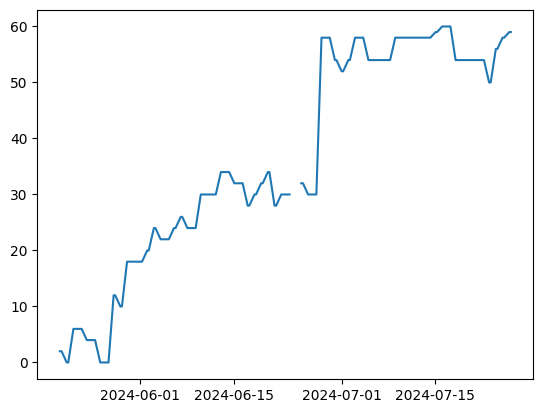

In [283]:
plt.plot(sfc_datetimes, sfc_vals)
plt.show()

Text(0.5, 1.0, 'bottom')

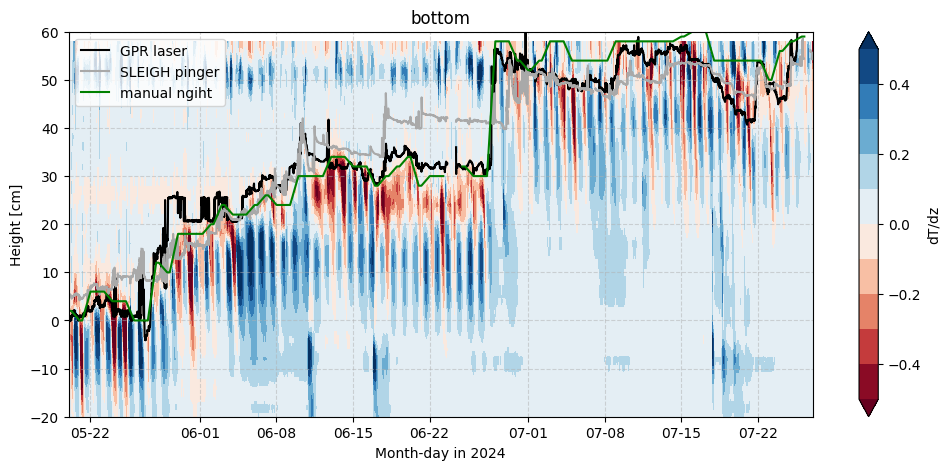

In [284]:


ylims = {'top':(0,80),'bottom':(-20,60)}
section = 'bottom'
simba_temps_section = separate_sections_data[section]['temperature']
simba_heights_section = separate_sections_data[section]['initial_height']
simba_dates_section = separate_sections_data[section]['dates']

dTdz_section = np.gradient(simba_temps_section, simba_heights_section,  axis=1)

fig, ax = plt.subplots(1, figsize=(12,5), sharex=True, sharey=True)
cb = ax.contourf(simba_dates_section, simba_heights_section, np.swapaxes(dTdz_section,0,1),
                cmap=plt.cm.RdBu, levels=np.arange(-.5,.51,.1), extend='both')
ax.plot(asfs_data_lev2['dates'], (asfs_data_lev2['snow_gpr_dist'][0]-asfs_data_lev2['snow_gpr_dist'])*100., label='GPR laser', c='k')
ax.plot( asfs_data_lev2['dates'], asfs_data_lev2['snow_depth'], label='SLEIGH pinger', c='darkgrey')
ax.plot(sfc_datetimes, sfc_vals, label='manual ngiht', c='g')

ax.set_ylabel('Height [cm]')
plt.colorbar(cb, label='dT/dz', ax=ax)
ax.grid(alpha=.5, ls='--')
    
ax.set_ylim(ylims[section])
ax.set_xlim(dt.datetime(2024,5,20), dt.datetime(2024,7,27))
ax.xaxis.set_major_formatter(myFmt)
ax.set_xlabel('Month-day in 2024')
ax.legend(loc='upper left')
plt.title(section)